# Traffic Sign Image Classification using CNN and Transfer Learning

**Module:** Artificial Intelligence and Machine Learning (6CS012)  
**Assessment:** Part II – Vision Task  
**Task:** Image classification using CNN from scratch and transfer learning  

This notebook includes:
- Dataset loading and visualization
- Baseline CNN model
- Deeper CNN with regularization
- Optimizer comparison: Adam vs SGD
- Ablation study by removing dropout
- Transfer learning using MobileNetV2
- Model evaluation and prediction comparison

In [15]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [16]:
# Import required libraries
import os
import time
import random
import json

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from PIL import Image, UnidentifiedImageError
from IPython.display import display

import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers, models
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.applications import MobileNetV2
from tensorflow.keras.applications.mobilenet_v2 import preprocess_input
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau, ModelCheckpoint

from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay
from sklearn.metrics import precision_recall_fscore_support
from sklearn.utils.class_weight import compute_class_weight

SEED = 7
random.seed(SEED)
np.random.seed(SEED)
tf.random.set_seed(SEED)

print('TensorFlow version:', tf.__version__)
print('GPU:', tf.config.list_physical_devices('GPU'))

TensorFlow version: 2.20.0
GPU: []


## 1. Dataset Path Setup

Update `DATASET_ROOT` if your folder location is different. The folder should contain `Train` and `Test` folders.

In [17]:
import os
import zipfile

try:
    from google.colab import drive
    drive.mount('/content/drive')
    IN_COLAB = True
except Exception:
    IN_COLAB = False

TRAIN_ZIP = "/content/drive/MyDrive/Ai Assessment/Train-20260430T065850Z-3-001 (1).zip"
TEST_ZIP = "/content/drive/MyDrive/Ai Assessment/Test-20260430T065848Z-3-001.zip"

DATASET_ROOT = "/content/traffic_sign_dataset"
TRAIN_DIR = os.path.join(DATASET_ROOT, "Train")
TEST_DIR = os.path.join(DATASET_ROOT, "Test")

os.makedirs(DATASET_ROOT, exist_ok=True)

def unzip_file(zip_path, extract_to):
    if not os.path.exists(zip_path):
        raise FileNotFoundError(f"Zip file not found: {zip_path}")

    with zipfile.ZipFile(zip_path, 'r') as zip_ref:
        zip_ref.extractall(extract_to)

    print("Extracted:", zip_path)

if not os.path.isdir(TRAIN_DIR):
    unzip_file(TRAIN_ZIP, DATASET_ROOT)

if not os.path.isdir(TEST_DIR):
    unzip_file(TEST_ZIP, DATASET_ROOT)

IMAGE_SIZE = (64, 64)
IMAGE_SHAPE = (64, 64, 3)
BATCH_SIZE = 32

# Reduced epochs to avoid overfitting
BASELINE_EPOCHS = 10
DEEP_EPOCHS = 12
TRANSFER_EPOCHS = 6
FINE_TUNE_EPOCHS = 4

OUTPUT_DIR = '/content/part2_outputs' if IN_COLAB else './part2_outputs'
os.makedirs(OUTPUT_DIR, exist_ok=True)

print('Dataset root:', DATASET_ROOT)
print('Training folder:', TRAIN_DIR)
print('Testing folder:', TEST_DIR)
print('Output folder:', OUTPUT_DIR)

print("Train exists:", os.path.isdir(TRAIN_DIR))
print("Test exists:", os.path.isdir(TEST_DIR))


Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Dataset root: /content/traffic_sign_dataset
Training folder: /content/traffic_sign_dataset/Train
Testing folder: /content/traffic_sign_dataset/Test
Output folder: /content/part2_outputs
Train exists: True
Test exists: True


## 2. Create DataFrames from Image Folders

The code scans image files and skips corrupted images. This makes the training process safer.

In [18]:
VALID_EXTENSIONS = ('.png', '.jpg', '.jpeg', '.bmp', '.ppm')


def check_image_validity(path):
    try:
        with Image.open(path) as image:
            image.verify()
        return True
    except (UnidentifiedImageError, OSError, ValueError):
        return False


def make_training_dataframe(train_folder):
    rows = []
    bad_files = []

    labels = sorted([
        folder for folder in os.listdir(train_folder)
        if os.path.isdir(os.path.join(train_folder, folder))
    ])

    for label in labels:
        class_folder = os.path.join(train_folder, label)
        for file_name in os.listdir(class_folder):
            if not file_name.lower().endswith(VALID_EXTENSIONS):
                continue
            file_path = os.path.join(class_folder, file_name)
            if check_image_validity(file_path):
                rows.append({'filepath': file_path, 'label': label, 'filename': file_name})
            else:
                bad_files.append(file_path)

    return pd.DataFrame(rows), labels, bad_files


def make_test_dataframe(test_folder):
    rows = []
    bad_files = []

    for file_name in sorted(os.listdir(test_folder)):
        file_path = os.path.join(test_folder, file_name)
        if not os.path.isfile(file_path):
            continue
        if not file_name.lower().endswith(VALID_EXTENSIONS):
            continue
        if check_image_validity(file_path):
            rows.append({'filepath': file_path, 'filename': file_name})
        else:
            bad_files.append(file_path)

    return pd.DataFrame(rows), bad_files

train_df, class_names, invalid_train = make_training_dataframe(TRAIN_DIR)
test_df, invalid_test = make_test_dataframe(TEST_DIR)

print('Number of classes:', len(class_names))
print('Classes:', class_names)
print('Training images:', len(train_df))
print('Test images:', len(test_df))
print('Invalid training images skipped:', len(invalid_train))
print('Invalid test images skipped:', len(invalid_test))

display(train_df.head())

Number of classes: 4
Classes: ['Caution', 'Instructions', 'No Passing', 'OverSpeed']
Training images: 15883
Test images: 4
Invalid training images skipped: 28
Invalid test images skipped: 0


,filepath,label,filename
0,/content/traffic_sign_dataset/Train/Caution/00...,Caution,00018_00016_00029.png
1,/content/traffic_sign_dataset/Train/Caution/00...,Caution,00018_00031_00014.png
2,/content/traffic_sign_dataset/Train/Caution/00...,Caution,00018_00002_00006.png
3,/content/traffic_sign_dataset/Train/Caution/00...,Caution,00018_00014_00024.png
4,/content/traffic_sign_dataset/Train/Caution/00...,Caution,00022_00009_00011.png


## 3. Dataset Understanding and Visualization

This section shows class distribution and sample images from the dataset.

,Class,Image Count
0,Caution,2422
1,Instructions,2841
2,No Passing,5378
3,OverSpeed,5242


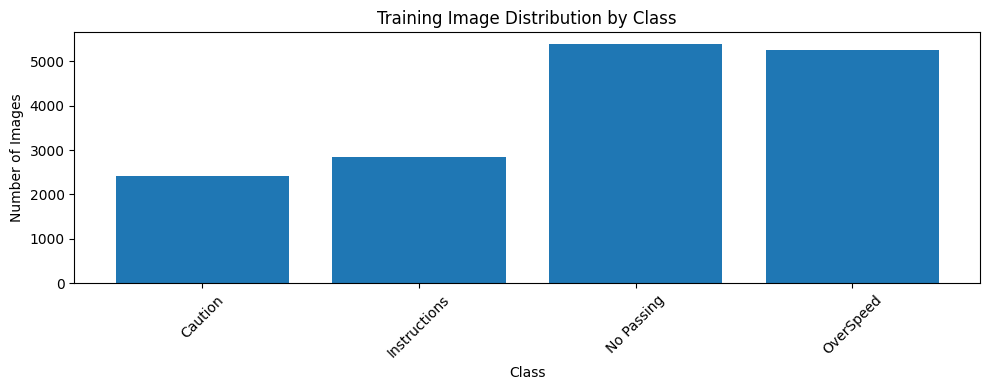

In [19]:
# Class distribution
class_counts = train_df['label'].value_counts().sort_index()

distribution_table = class_counts.rename_axis('Class').reset_index(name='Image Count')
display(distribution_table)

plt.figure(figsize=(10, 4))
plt.bar(distribution_table['Class'], distribution_table['Image Count'])
plt.title('Training Image Distribution by Class')
plt.xlabel('Class')
plt.ylabel('Number of Images')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

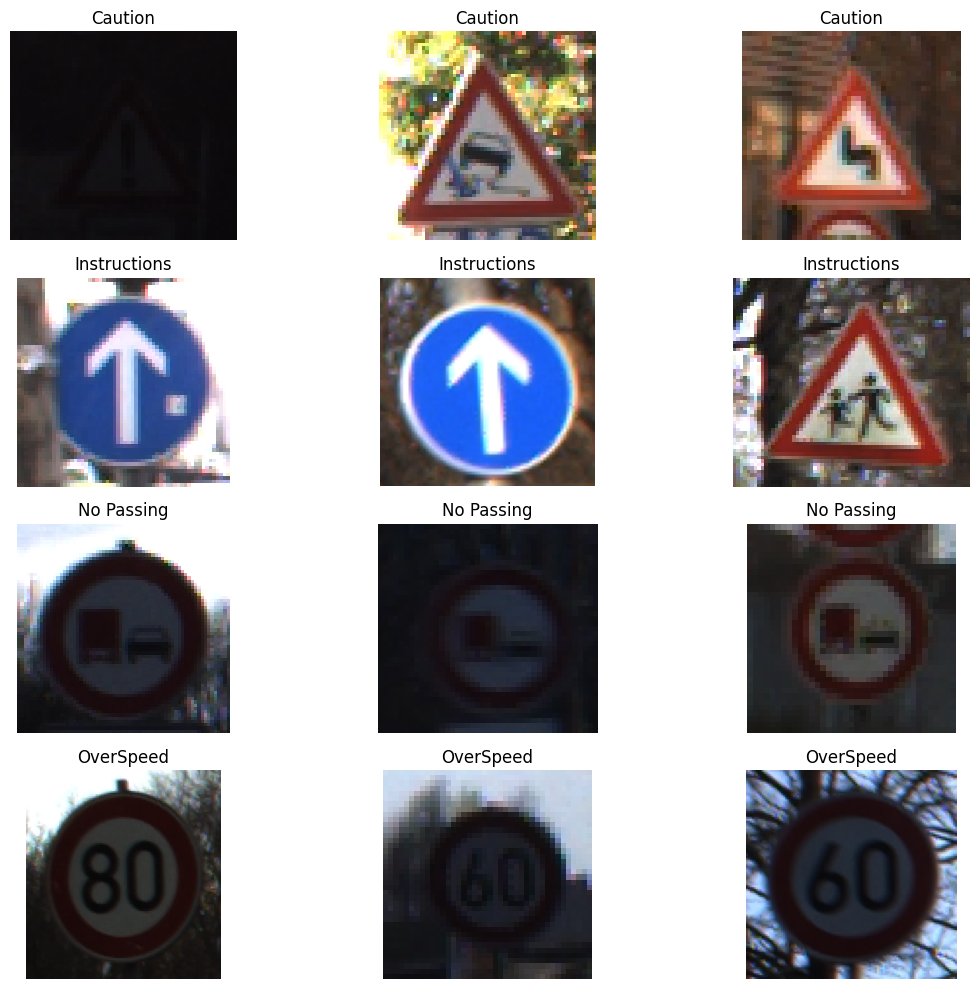

In [20]:
# Display sample images
sample_classes = class_names[:6]
samples_per_class = 3

plt.figure(figsize=(12, 10))
plot_number = 1

for class_label in sample_classes:
    class_data = train_df[train_df['label'] == class_label]
    samples = class_data.sample(min(samples_per_class, len(class_data)), random_state=SEED)

    for _, row in samples.iterrows():
        image = Image.open(row['filepath']).convert('RGB')
        plt.subplot(len(sample_classes), samples_per_class, plot_number)
        plt.imshow(image)
        plt.title(class_label)
        plt.axis('off')
        plot_number += 1

plt.tight_layout()
plt.show()

## 4. Train and Validation Split

The dataset is split into 80% training and 20% validation using stratification to preserve class distribution.

In [21]:
train_data, val_data = train_test_split(
    train_df,
    test_size=0.20,
    stratify=train_df['label'],
    random_state=SEED
)

train_data = train_data.reset_index(drop=True)
val_data = val_data.reset_index(drop=True)

# Class weights only needed when classes are highly imbalanced
class_weight_values = compute_class_weight(
    class_weight='balanced',
    classes=np.array(class_names),
    y=train_data['label'].values
)

class_weights = {i: float(weight) for i, weight in enumerate(class_weight_values)}

print('Train images:', len(train_data))
print('Validation images:', len(val_data))
print('Class weights:', class_weights)


Train images: 12706
Validation images: 3177
Class weights: {0: 1.6390608875128998, 1: 1.397492300923889, 2: 0.7383774988377498, 3: 0.7575721440496065}


## 5. Image Preprocessing and Data Generators

Images are resized to 128×128 and normalized. Augmentation is applied only to the training generator.

In [22]:
train_datagen = ImageDataGenerator(
    rescale=1.0/255.0,
    rotation_range=20,
    width_shift_range=0.15,
    height_shift_range=0.15,
    zoom_range=0.20,
    shear_range=0.10,
    horizontal_flip=False,
    brightness_range=(0.75, 1.25),
    fill_mode='nearest'
)

valid_datagen = ImageDataGenerator(rescale=1.0/255.0)

train_generator = train_datagen.flow_from_dataframe(
    dataframe=train_data,
    x_col='filepath',
    y_col='label',
    target_size=IMAGE_SIZE,
    class_mode='categorical',
    classes=class_names,
    batch_size=BATCH_SIZE,
    shuffle=True,
    seed=SEED
)

val_generator = valid_datagen.flow_from_dataframe(
    dataframe=val_data,
    x_col='filepath',
    y_col='label',
    target_size=IMAGE_SIZE,
    class_mode='categorical',
    classes=class_names,
    batch_size=BATCH_SIZE,
    shuffle=False
)

test_generator = valid_datagen.flow_from_dataframe(
    dataframe=test_df,
    x_col='filepath',
    y_col=None,
    target_size=IMAGE_SIZE,
    class_mode=None,
    batch_size=BATCH_SIZE,
    shuffle=False
)


Found 12706 validated image filenames belonging to 4 classes.
Found 3177 validated image filenames belonging to 4 classes.
Found 4 validated image filenames.


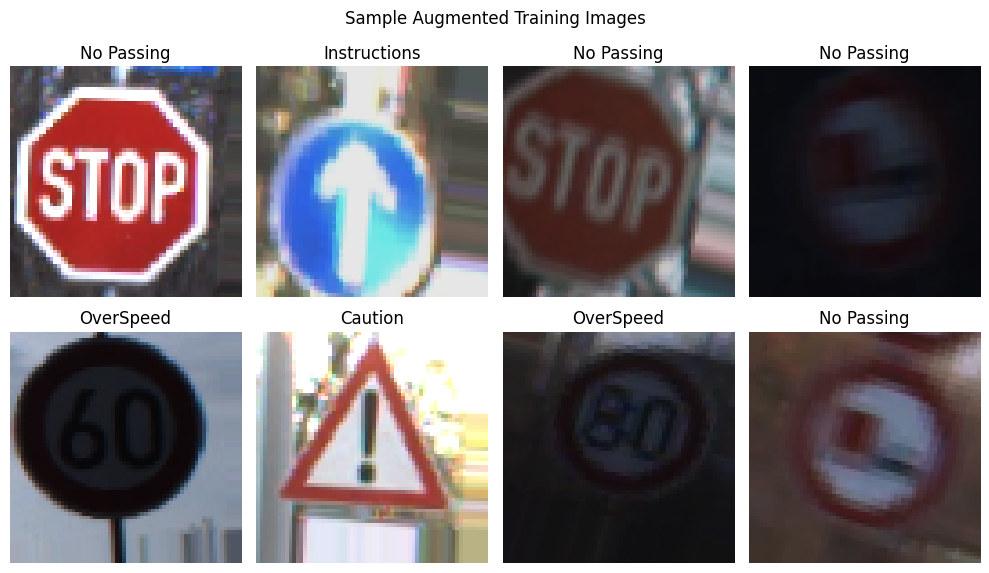

In [23]:
# Visualize a few augmented images
images, labels = next(train_generator)

plt.figure(figsize=(10, 6))
for i in range(min(8, len(images))):
    plt.subplot(2, 4, i + 1)
    plt.imshow(images[i])
    plt.title(class_names[np.argmax(labels[i])])
    plt.axis('off')

plt.suptitle('Sample Augmented Training Images')
plt.tight_layout()
plt.show()

## 6. Helper Functions for Training and Evaluation

In [24]:
def training_callbacks(model_name):
    return [
        EarlyStopping(monitor='val_loss', patience=3, restore_best_weights=True),
        ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=2, verbose=1),
        ModelCheckpoint(
            filepath=os.path.join(OUTPUT_DIR, model_name + '_best.keras'),
            monitor='val_accuracy',
            save_best_only=True
        )
    ]


def plot_model_history(history, title):
    plt.figure(figsize=(7, 4))
    plt.plot(history.history['accuracy'], label='Train Accuracy')
    plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
    plt.title(title + ' Accuracy')
    plt.xlabel('Epoch')
    plt.ylabel('Accuracy')
    plt.legend()
    plt.show()

    plt.figure(figsize=(7, 4))
    plt.plot(history.history['loss'], label='Train Loss')
    plt.plot(history.history['val_loss'], label='Validation Loss')
    plt.title(title + ' Loss')
    plt.xlabel('Epoch')
    plt.ylabel('Loss')
    plt.legend()
    plt.show()


def evaluate_model(model, generator, model_name):
    generator.reset()
    loss, accuracy = model.evaluate(generator, verbose=1)

    generator.reset()
    predictions = model.predict(generator, verbose=1)
    predicted_classes = np.argmax(predictions, axis=1)
    actual_classes = generator.classes

    precision, recall, f1, _ = precision_recall_fscore_support(
        actual_classes,
        predicted_classes,
        average='weighted',
        zero_division=0
    )

    print('' + model_name + ' Results')
    print('Loss:', round(loss, 4))
    print('Accuracy:', round(accuracy, 4))
    print('Precision:', round(precision, 4))
    print('Recall:', round(recall, 4))
    print('F1 Score:', round(f1, 4))
    print('Classification Report')
    print(classification_report(actual_classes, predicted_classes, target_names=class_names, zero_division=0))

    cm = confusion_matrix(actual_classes, predicted_classes)
    ConfusionMatrixDisplay(cm, display_labels=class_names).plot(values_format='d')
    plt.title(model_name + ' Confusion Matrix')
    plt.xticks(rotation=45)
    plt.show()

    return {
        'loss': loss,
        'accuracy': accuracy,
        'precision': precision,
        'recall': recall,
        'f1_score': f1
    }


def predict_test_images(model, generator, file_names, model_name):
    generator.reset()
    predictions = model.predict(generator, verbose=1)
    predicted_index = np.argmax(predictions, axis=1)
    confidence = np.max(predictions, axis=1)

    output = pd.DataFrame({
        'filename': file_names,
        'predicted_class': [class_names[i] for i in predicted_index],
        'confidence': confidence
    })

    save_path = os.path.join(OUTPUT_DIR, model_name.replace(' ', '_') + '_test_predictions.csv')
    output.to_csv(save_path, index=False)
    print('Saved prediction file:', save_path)
    return output


## 7. Baseline CNN Model

The baseline model follows the assignment requirement: three convolutional layers with pooling, three fully connected layers, and an output layer.

In [25]:
from tensorflow.keras import regularizers

def build_baseline_cnn(input_shape, number_of_classes):
    model = models.Sequential([
        layers.Input(shape=input_shape),

        layers.Conv2D(32, (3, 3), activation='relu', padding='same',
                      kernel_regularizer=regularizers.l2(1e-4)),
        layers.MaxPooling2D((2, 2)),

        layers.Conv2D(64, (3, 3), activation='relu', padding='same',
                      kernel_regularizer=regularizers.l2(1e-4)),
        layers.MaxPooling2D((2, 2)),

        layers.Conv2D(64, (3, 3), activation='relu', padding='same',
                      kernel_regularizer=regularizers.l2(1e-4)),
        layers.MaxPooling2D((2, 2)),

        layers.Flatten(),
        layers.Dense(128, activation='relu', kernel_regularizer=regularizers.l2(1e-4)),
        layers.Dropout(0.50),
        layers.Dense(64, activation='relu'),
        layers.Dropout(0.40),
        layers.Dense(number_of_classes, activation='softmax')
    ])

    model.compile(
        optimizer=keras.optimizers.Adam(learning_rate=0.0005),
        loss='categorical_crossentropy',
        metrics=['accuracy']
    )

    return model

baseline_cnn = build_baseline_cnn(IMAGE_SHAPE, len(class_names))
baseline_cnn.summary()


Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_3 (Conv2D)               │ (None, 64, 64, 32)     │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 32, 32, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_4 (Conv2D)               │ (None, 32, 32, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_4 (MaxPooling2D)  │ (None, 16, 16, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_5 (Conv2D)               │ (None, 16, 16, 64)     │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_5 (MaxPooling2D)  │ (None, 8, 8, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_1 (Flatten)             │ (None, 4096)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 128)            │       524,416 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 4)              │           260 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 589,252 (2.25 MB)

 Trainable params: 589,252 (2.25 MB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/10
398/398 ━━━━━━━━━━━━━━━━━━━━ 157s 380ms/step - accuracy: 0.6306 - loss: 0.8720 - val_accuracy: 0.9311 - val_loss: 0.2551 - learning_rate: 5.0000e-04
Epoch 2/10
398/398 ━━━━━━━━━━━━━━━━━━━━ 138s 346ms/step - accuracy: 0.8834 - loss: 0.3636 - val_accuracy: 0.9600 - val_loss: 0.1234 - learning_rate: 5.0000e-04
Epoch 3/10
398/398 ━━━━━━━━━━━━━━━━━━━━ 137s 345ms/step - accuracy: 0.9299 - loss: 0.2361 - val_accuracy: 0.9836 - val_loss: 0.0855 - learning_rate: 5.0000e-04
Epoch 4/10
398/398 ━━━━━━━━━━━━━━━━━━━━ 139s 349ms/step - accuracy: 0.9559 - loss: 0.1667 - val_accuracy: 0.9906 - val_loss: 0.0580 - learning_rate: 5.0000e-04
Epoch 5/10
398/398 ━━━━━━━━━━━━━━━━━━━━ 135s 340ms/step - accuracy: 0.9680 - loss: 0.1287 - val_accuracy: 0.9937 - val_loss: 0.0503 - learning_rate: 5.0000e-04
Epoch 6/10
398/398 ━━━━━━━━━━━━━━━━━━━━ 144s 345ms/step - accuracy: 0.9779 - loss: 0.1032 - val_accuracy: 0.9981 - val_loss: 0.0444 - learning_rate: 5.0000e-04
Epoch 7/10
398/398 ━━━━━━━━━━━━━━━━━━━━ 

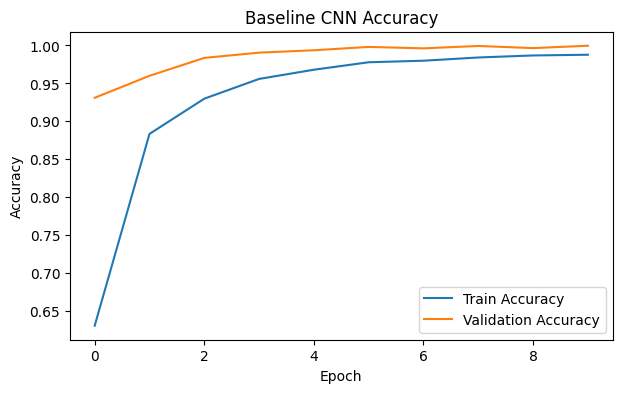

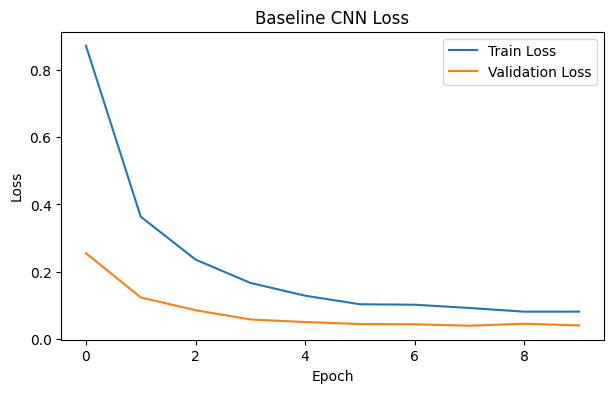

100/100 ━━━━━━━━━━━━━━━━━━━━ 10s 96ms/step - accuracy: 0.9994 - loss: 0.0393
100/100 ━━━━━━━━━━━━━━━━━━━━ 8s 78ms/step
Baseline CNN Results
Loss: 0.0393
Accuracy: 0.9994
Precision: 0.9994
Recall: 0.9994
F1 Score: 0.9994
Classification Report
              precision    recall  f1-score   support

     Caution       1.00      1.00      1.00       484
Instructions       1.00      1.00      1.00       568
  No Passing       1.00      1.00      1.00      1076
   OverSpeed       1.00      1.00      1.00      1049

    accuracy                           1.00      3177
   macro avg       1.00      1.00      1.00      3177
weighted avg       1.00      1.00      1.00      3177



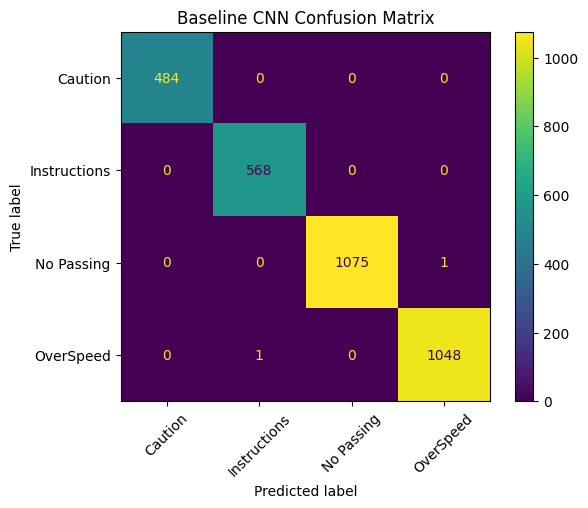

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 110ms/step
Saved prediction file: /content/part2_outputs/Baseline_CNN_test_predictions.csv
Baseline training time: 1399.07 seconds


In [26]:
start_time = time.time()

baseline_history = baseline_cnn.fit(
    train_generator,
    validation_data=val_generator,
    epochs=BASELINE_EPOCHS,
    callbacks=training_callbacks('baseline_cnn'),
    verbose=1
)

baseline_time = time.time() - start_time

plot_model_history(baseline_history, 'Baseline CNN')
baseline_metrics = evaluate_model(baseline_cnn, val_generator, 'Baseline CNN')
baseline_metrics['training_time_seconds'] = baseline_time

baseline_test_predictions = predict_test_images(
    baseline_cnn,
    test_generator,
    test_df['filename'].tolist(),
    'Baseline CNN'
)

print('Baseline training time:', round(baseline_time, 2), 'seconds')


## 8. Sample Prediction Visualization

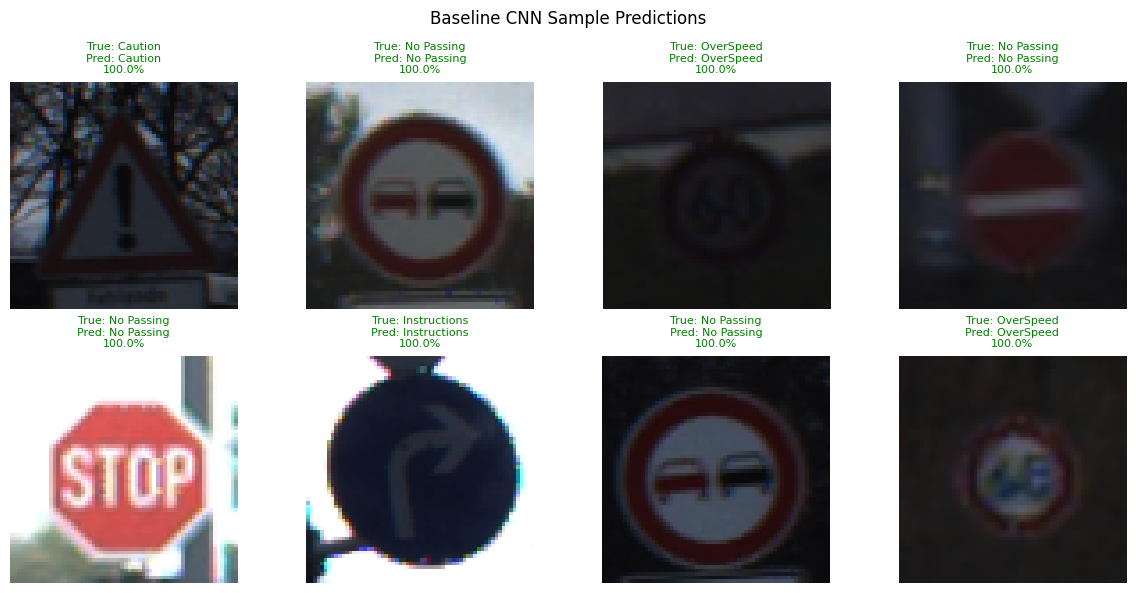

In [27]:
def show_prediction_examples(model, dataframe, title, sample_size=8):
    samples = dataframe.sample(sample_size, random_state=SEED).reset_index(drop=True)

    plt.figure(figsize=(12, 6))

    for i, row in samples.iterrows():

        image = Image.open(row['filepath']).convert('RGB').resize(IMAGE_SIZE)

        image_array = np.array(image, dtype=np.float32) / 255.0

        prediction = model.predict(image_array[np.newaxis, ...], verbose=0)

        predicted_label = class_names[np.argmax(prediction)]

        actual_label = row['label']

        confidence = np.max(prediction)

        title_color = 'green' if predicted_label == actual_label else 'red'

        plt.subplot(2, 4, i + 1)

        plt.imshow(image)

        plt.title(
            f"True: {actual_label}\nPred: {predicted_label}\n{confidence:.1%}",
            color=title_color,
            fontsize=8
        )

        plt.axis('off')

    plt.suptitle(title)

    plt.tight_layout()

    plt.show()


show_prediction_examples(
    baseline_cnn,
    val_data,
    'Baseline CNN Sample Predictions'
)

## 9. Deeper CNN Model with Regularization

This model has more convolutional layers than the baseline and uses Batch Normalization and Dropout.

In [28]:
def build_deep_cnn(input_shape, number_of_classes, optimizer_type='adam'):
    model = models.Sequential([
        layers.Input(shape=input_shape),

        layers.Conv2D(32, (3, 3), activation='relu', padding='same',
                      kernel_regularizer=regularizers.l2(1e-4)),
        layers.BatchNormalization(),
        layers.Conv2D(32, (3, 3), activation='relu', padding='same'),
        layers.MaxPooling2D((2, 2)),
        layers.Dropout(0.30),

        layers.Conv2D(64, (3, 3), activation='relu', padding='same',
                      kernel_regularizer=regularizers.l2(1e-4)),
        layers.BatchNormalization(),
        layers.Conv2D(64, (3, 3), activation='relu', padding='same'),
        layers.MaxPooling2D((2, 2)),
        layers.Dropout(0.35),

        layers.Conv2D(128, (3, 3), activation='relu', padding='same',
                      kernel_regularizer=regularizers.l2(1e-4)),
        layers.BatchNormalization(),
        layers.MaxPooling2D((2, 2)),
        layers.Dropout(0.40),

        layers.Flatten(),
        layers.Dense(256, activation='relu', kernel_regularizer=regularizers.l2(1e-4)),
        layers.BatchNormalization(),
        layers.Dropout(0.55),
        layers.Dense(128, activation='relu'),
        layers.Dropout(0.45),
        layers.Dense(number_of_classes, activation='softmax')
    ])

    if optimizer_type == 'sgd':
        optimizer = keras.optimizers.SGD(learning_rate=0.005, momentum=0.9)
    else:
        optimizer = keras.optimizers.Adam(learning_rate=0.0005)

    model.compile(
        optimizer=optimizer,
        loss='categorical_crossentropy',
        metrics=['accuracy']
    )

    return model

deep_cnn_adam = build_deep_cnn(IMAGE_SHAPE, len(class_names), optimizer_type='adam')
deep_cnn_adam.summary()


Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_6 (Conv2D)               │ (None, 64, 64, 32)     │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 64, 64, 32)     │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_7 (Conv2D)               │ (None, 64, 64, 32)     │         9,248 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_6 (MaxPooling2D)  │ (None, 32, 32, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_4 (Dropout)             │ (None, 32, 32, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_8 (Conv2D)               │ (None, 32, 32, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 32, 32, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_9 (Conv2D)               │ (None, 32, 32, 64)     │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_7 (MaxPooling2D)  │ (None, 16, 16, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_5 (Dropout)             │ (None, 16, 16, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_10 (Conv2D)              │ (None, 16, 16, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 16, 16, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_8 (MaxPooling2D)  │ (None, 8, 8, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_6 (Dropout)             │ (None, 8, 8, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_2 (Flatten)             │ (None, 8192)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_6 (Dense)                 │ (None, 256)            │     2,097,408 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_3           │ (None, 256)            │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_7 (Dropout)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_7 (Dense)                 │ (None, 128)            │        32,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_8 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_8 (Dense)                 │ (None, 4)              │           516 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,272,164 (8.67 MB)

 Trainable params: 2,271,204 (8.66 MB)

 Non-trainable params: 960 (3.75 KB)

Epoch 1/12
398/398 ━━━━━━━━━━━━━━━━━━━━ 407s 1s/step - accuracy: 0.5991 - loss: 1.1453 - val_accuracy: 0.4706 - val_loss: 1.8875 - learning_rate: 5.0000e-04
Epoch 2/12
398/398 ━━━━━━━━━━━━━━━━━━━━ 400s 1s/step - accuracy: 0.8141 - loss: 0.5667 - val_accuracy: 0.8502 - val_loss: 0.9651 - learning_rate: 5.0000e-04
Epoch 3/12
398/398 ━━━━━━━━━━━━━━━━━━━━ 399s 1s/step - accuracy: 0.8979 - loss: 0.3609 - val_accuracy: 0.9204 - val_loss: 0.4507 - learning_rate: 5.0000e-04
Epoch 4/12
398/398 ━━━━━━━━━━━━━━━━━━━━ 398s 1s/step - accuracy: 0.9167 - loss: 0.3181 - val_accuracy: 0.9758 - val_loss: 0.1494 - learning_rate: 5.0000e-04
Epoch 5/12
398/398 ━━━━━━━━━━━━━━━━━━━━ 399s 1s/step - accuracy: 0.9414 - loss: 0.2498 - val_accuracy: 0.9843 - val_loss: 0.1324 - learning_rate: 5.0000e-04
Epoch 6/12
398/398 ━━━━━━━━━━━━━━━━━━━━ 444s 1s/step - accuracy: 0.9558 - loss: 0.2128 - val_accuracy: 0.9418 - val_loss: 0.3766 - learning_rate: 5.0000e-04
Epoch 7/12
398/398 ━━━━━━━━━━━━━━━━━━━━ 421s 1s/step - acc

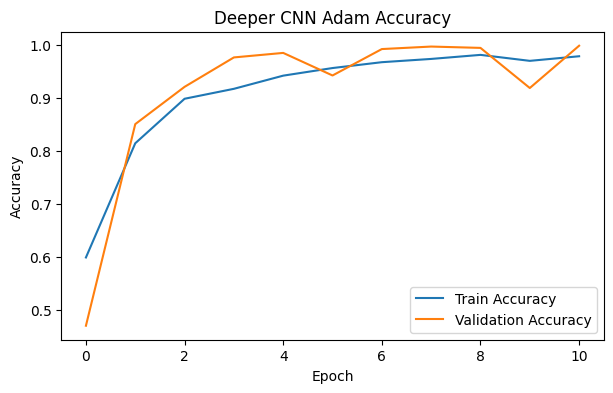

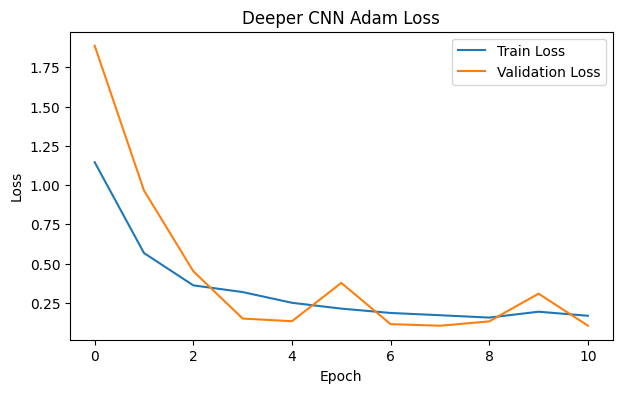

100/100 ━━━━━━━━━━━━━━━━━━━━ 23s 232ms/step - accuracy: 0.9962 - loss: 0.1037
100/100 ━━━━━━━━━━━━━━━━━━━━ 21s 210ms/step
Deeper CNN Adam Results
Loss: 0.1037
Accuracy: 0.9962
Precision: 0.9962
Recall: 0.9962
F1 Score: 0.9962
Classification Report
              precision    recall  f1-score   support

     Caution       0.99      0.99      0.99       484
Instructions       0.99      0.99      0.99       568
  No Passing       1.00      1.00      1.00      1076
   OverSpeed       1.00      1.00      1.00      1049

    accuracy                           1.00      3177
   macro avg       1.00      1.00      1.00      3177
weighted avg       1.00      1.00      1.00      3177



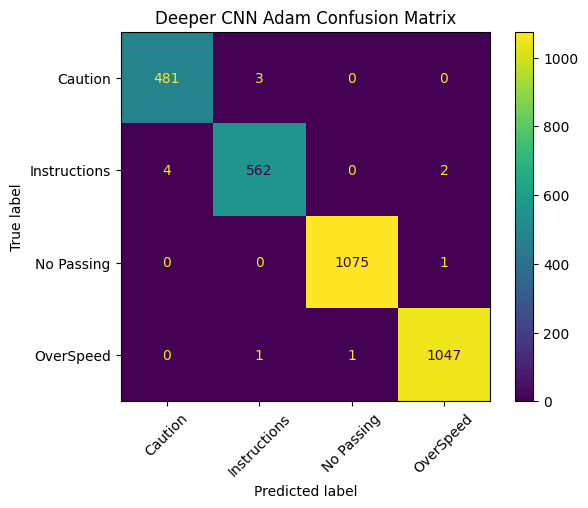

Deeper CNN Adam training time: 4526.67 seconds


In [29]:
start_time = time.time()

deep_adam_history = deep_cnn_adam.fit(
    train_generator,
    validation_data=val_generator,
    epochs=DEEP_EPOCHS,
    callbacks=training_callbacks('deep_cnn_adam'),
    verbose=1
)

deep_adam_time = time.time() - start_time

plot_model_history(deep_adam_history, 'Deeper CNN Adam')

deep_adam_metrics = evaluate_model(
    deep_cnn_adam,
    val_generator,
    'Deeper CNN Adam'
)

deep_adam_metrics['training_time_seconds'] = deep_adam_time

print('Deeper CNN Adam training time:', round(deep_adam_time, 2), 'seconds')


## 10. Optimizer Comparison: SGD vs Adam

The same deeper CNN architecture is trained using SGD to compare optimizer performance.

Model: "sequential_3"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_11 (Conv2D)              │ (None, 64, 64, 32)     │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_4           │ (None, 64, 64, 32)     │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_12 (Conv2D)              │ (None, 64, 64, 32)     │         9,248 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_9 (MaxPooling2D)  │ (None, 32, 32, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_9 (Dropout)             │ (None, 32, 32, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_13 (Conv2D)              │ (None, 32, 32, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_5           │ (None, 32, 32, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_14 (Conv2D)              │ (None, 32, 32, 64)     │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_10 (MaxPooling2D) │ (None, 16, 16, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_10 (Dropout)            │ (None, 16, 16, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_15 (Conv2D)              │ (None, 16, 16, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_6           │ (None, 16, 16, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_11 (MaxPooling2D) │ (None, 8, 8, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_11 (Dropout)            │ (None, 8, 8, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_3 (Flatten)             │ (None, 8192)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_9 (Dense)                 │ (None, 256)            │     2,097,408 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_7           │ (None, 256)            │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_12 (Dropout)            │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_10 (Dense)                │ (None, 128)            │        32,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_13 (Dropout)            │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_11 (Dense)                │ (None, 4)              │           516 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,272,164 (8.67 MB)

 Trainable params: 2,271,204 (8.66 MB)

 Non-trainable params: 960 (3.75 KB)

Epoch 1/12
398/398 ━━━━━━━━━━━━━━━━━━━━ 398s 988ms/step - accuracy: 0.5386 - loss: 1.2274 - val_accuracy: 0.5011 - val_loss: 1.5981 - learning_rate: 0.0050
Epoch 2/12
398/398 ━━━━━━━━━━━━━━━━━━━━ 442s 989ms/step - accuracy: 0.7472 - loss: 0.7243 - val_accuracy: 0.8244 - val_loss: 0.6347 - learning_rate: 0.0050
Epoch 3/12
398/398 ━━━━━━━━━━━━━━━━━━━━ 394s 991ms/step - accuracy: 0.8373 - loss: 0.5240 - val_accuracy: 0.8980 - val_loss: 0.3540 - learning_rate: 0.0050
Epoch 4/12
398/398 ━━━━━━━━━━━━━━━━━━━━ 393s 988ms/step - accuracy: 0.8531 - loss: 0.4968 - val_accuracy: 0.4410 - val_loss: 2.1672 - learning_rate: 0.0050
Epoch 5/12
398/398 ━━━━━━━━━━━━━━━━━━━━ 0s 922ms/step - accuracy: 0.7775 - loss: 0.8213
Epoch 5: ReduceLROnPlateau reducing learning rate to 0.0024999999441206455.
398/398 ━━━━━━━━━━━━━━━━━━━━ 389s 976ms/step - accuracy: 0.8094 - loss: 0.7372 - val_accuracy: 0.8697 - val_loss: 0.7190 - learning_rate: 0.0050
Epoch 6/12
398/398 ━━━━━━━━━━━━━━━━━━━━ 391s 984ms/step - accuracy:

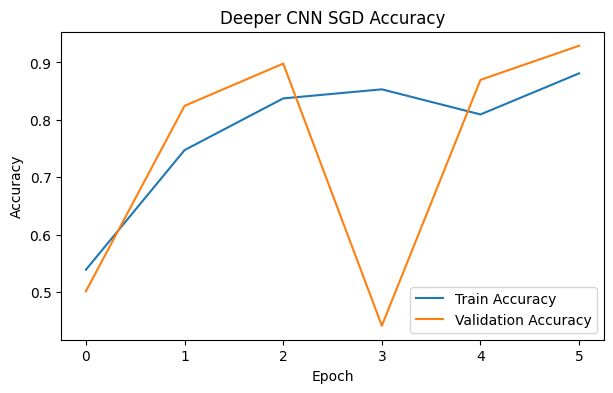

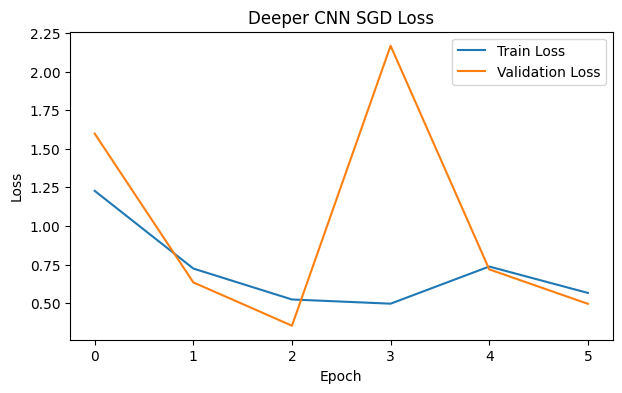

100/100 ━━━━━━━━━━━━━━━━━━━━ 21s 211ms/step - accuracy: 0.8980 - loss: 0.3540
100/100 ━━━━━━━━━━━━━━━━━━━━ 24s 232ms/step
Deeper CNN SGD Results
Loss: 0.354
Accuracy: 0.898
Precision: 0.9104
Recall: 0.898
F1 Score: 0.8986
Classification Report
              precision    recall  f1-score   support

     Caution       0.73      0.90      0.81       484
Instructions       0.99      0.74      0.84       568
  No Passing       0.98      0.91      0.95      1076
   OverSpeed       0.88      0.96      0.92      1049

    accuracy                           0.90      3177
   macro avg       0.90      0.88      0.88      3177
weighted avg       0.91      0.90      0.90      3177



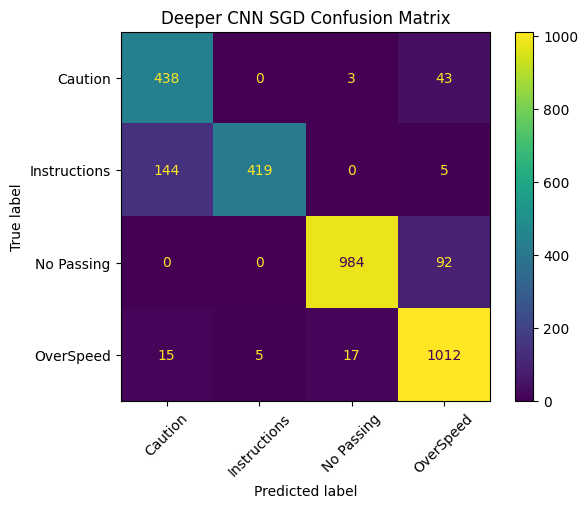

Deeper CNN SGD training time: 2457.77 seconds


In [30]:
deep_cnn_sgd = build_deep_cnn(IMAGE_SHAPE, len(class_names), optimizer_type='sgd')
deep_cnn_sgd.summary()

start_time = time.time()

deep_sgd_history = deep_cnn_sgd.fit(
    train_generator,
    validation_data=val_generator,
    epochs=DEEP_EPOCHS,
    callbacks=training_callbacks('deep_cnn_sgd'),
    verbose=1
)

deep_sgd_time = time.time() - start_time

plot_model_history(deep_sgd_history, 'Deeper CNN SGD')
deep_sgd_metrics = evaluate_model(deep_cnn_sgd, val_generator, 'Deeper CNN SGD')
deep_sgd_metrics['training_time_seconds'] = deep_sgd_time

print('Deeper CNN SGD training time:', round(deep_sgd_time, 2), 'seconds')


In [ ]:
# Adam vs SGD curve comparison
plt.figure(figsize=(8, 4))
plt.plot(deep_adam_history.history['val_accuracy'], label='Adam Validation Accuracy')
plt.plot(deep_sgd_history.history['val_accuracy'], label='SGD Validation Accuracy')
plt.title('Optimizer Comparison: Adam vs SGD')
plt.xlabel('Epoch')
plt.ylabel('Validation Accuracy')
plt.legend()
plt.show()

print('Adam Accuracy:', round(deep_adam_metrics['accuracy'], 4))
print('SGD Accuracy:', round(deep_sgd_metrics['accuracy'], 4))

## 11. Ablation Study: Removing Dropout

This experiment removes dropout from the deeper CNN to observe whether regularization improves generalization.

In [32]:
def build_no_dropout_cnn(input_shape, number_of_classes):
    model = models.Sequential([
        layers.Input(shape=input_shape),

        layers.Conv2D(32, (3, 3), activation='relu', padding='same',
                      kernel_regularizer=regularizers.l2(1e-4)),
        layers.BatchNormalization(),
        layers.Conv2D(32, (3, 3), activation='relu', padding='same'),
        layers.MaxPooling2D((2, 2)),

        layers.Conv2D(64, (3, 3), activation='relu', padding='same',
                      kernel_regularizer=regularizers.l2(1e-4)),
        layers.BatchNormalization(),
        layers.Conv2D(64, (3, 3), activation='relu', padding='same'),
        layers.MaxPooling2D((2, 2)),

        layers.Conv2D(128, (3, 3), activation='relu', padding='same',
                      kernel_regularizer=regularizers.l2(1e-4)),
        layers.BatchNormalization(),
        layers.MaxPooling2D((2, 2)),

        layers.Flatten(),
        layers.Dense(256, activation='relu', kernel_regularizer=regularizers.l2(1e-4)),
        layers.BatchNormalization(),
        layers.Dense(128, activation='relu'),
        layers.Dense(number_of_classes, activation='softmax')
    ])

    model.compile(
        optimizer=keras.optimizers.Adam(learning_rate=0.0005),
        loss='categorical_crossentropy',
        metrics=['accuracy']
    )

    return model

no_dropout_cnn = build_no_dropout_cnn(IMAGE_SHAPE, len(class_names))
no_dropout_cnn.summary()


Model: "sequential_4"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_16 (Conv2D)              │ (None, 64, 64, 32)     │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_8           │ (None, 64, 64, 32)     │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_17 (Conv2D)              │ (None, 64, 64, 32)     │         9,248 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_12 (MaxPooling2D) │ (None, 32, 32, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_18 (Conv2D)              │ (None, 32, 32, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_9           │ (None, 32, 32, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_19 (Conv2D)              │ (None, 32, 32, 64)     │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_13 (MaxPooling2D) │ (None, 16, 16, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_20 (Conv2D)              │ (None, 16, 16, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_10          │ (None, 16, 16, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_14 (MaxPooling2D) │ (None, 8, 8, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_4 (Flatten)             │ (None, 8192)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_12 (Dense)                │ (None, 256)            │     2,097,408 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_11          │ (None, 256)            │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_13 (Dense)                │ (None, 128)            │        32,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_14 (Dense)                │ (None, 4)              │           516 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,272,164 (8.67 MB)

 Trainable params: 2,271,204 (8.66 MB)

 Non-trainable params: 960 (3.75 KB)

In [ ]:
start_time = time.time()

no_dropout_history = no_dropout_cnn.fit(
    train_generator,
    validation_data=val_generator,
    epochs=DEEP_EPOCHS,
    callbacks=training_callbacks('no_dropout_cnn'),
    verbose=1
)

no_dropout_time = time.time() - start_time

plot_model_history(no_dropout_history, 'Ablation No Dropout')
no_dropout_metrics = evaluate_model(no_dropout_cnn, val_generator, 'Ablation No Dropout')
no_dropout_metrics['training_time_seconds'] = no_dropout_time

print('No Dropout training time:', round(no_dropout_time, 2), 'seconds')

full_gap = deep_adam_history.history['accuracy'][-1] - deep_adam_history.history['val_accuracy'][-1]
no_drop_gap = no_dropout_history.history['accuracy'][-1] - no_dropout_history.history['val_accuracy'][-1]

print('Train-validation gap with dropout:', round(full_gap, 4))
print('Train-validation gap without dropout:', round(no_drop_gap, 4))


Epoch 1/12
398/398 ━━━━━━━━━━━━━━━━━━━━ 393s 977ms/step - accuracy: 0.8788 - loss: 0.3863 - val_accuracy: 0.8618 - val_loss: 0.5269 - learning_rate: 5.0000e-04
Epoch 2/12
398/398 ━━━━━━━━━━━━━━━━━━━━ 407s 1s/step - accuracy: 0.9759 - loss: 0.1355 - val_accuracy: 0.9893 - val_loss: 0.1027 - learning_rate: 5.0000e-04
Epoch 3/12
398/398 ━━━━━━━━━━━━━━━━━━━━ 387s 974ms/step - accuracy: 0.9850 - loss: 0.1163 - val_accuracy: 0.9959 - val_loss: 0.0848 - learning_rate: 5.0000e-04
Epoch 4/12
398/398 ━━━━━━━━━━━━━━━━━━━━ 441s 971ms/step - accuracy: 0.9766 - loss: 0.1354 - val_accuracy: 0.9969 - val_loss: 0.0926 - learning_rate: 5.0000e-04
Epoch 5/12
398/398 ━━━━━━━━━━━━━━━━━━━━ 0s 922ms/step - accuracy: 0.9894 - loss: 0.1075
Epoch 5: ReduceLROnPlateau reducing learning rate to 0.0002500000118743628.
398/398 ━━━━━━━━━━━━━━━━━━━━ 464s 1s/step - accuracy: 0.9887 - loss: 0.1084 - val_accuracy: 0.9487 - val_loss: 0.2214 - learning_rate: 5.0000e-04
Epoch 6/12
398/398 ━━━━━━━━━━━━━━━━━━━━ 0s 917ms/step

## 12. Transfer Learning with MobileNetV2

MobileNetV2 is used as the pretrained model. The convolutional base is first frozen, then the last layers are fine-tuned with a small learning rate.

In [ ]:
TRANSFER_SIZE = (224, 224)

transfer_train_datagen = ImageDataGenerator(
    preprocessing_function=preprocess_input,
    rotation_range=15,
    width_shift_range=0.10,
    height_shift_range=0.10,
    zoom_range=0.10,
    brightness_range=(0.85, 1.15),
    fill_mode='nearest'
)

transfer_valid_datagen = ImageDataGenerator(preprocessing_function=preprocess_input)

transfer_train_generator = transfer_train_datagen.flow_from_dataframe(
    dataframe=train_data,
    x_col='filepath',
    y_col='label',
    target_size=TRANSFER_SIZE,
    class_mode='categorical',
    classes=class_names,
    batch_size=BATCH_SIZE,
    shuffle=True,
    seed=SEED
)

transfer_val_generator = transfer_valid_datagen.flow_from_dataframe(
    dataframe=val_data,
    x_col='filepath',
    y_col='label',
    target_size=TRANSFER_SIZE,
    class_mode='categorical',
    classes=class_names,
    batch_size=BATCH_SIZE,
    shuffle=False
)

transfer_test_generator = transfer_valid_datagen.flow_from_dataframe(
    dataframe=test_df,
    x_col='filepath',
    y_col=None,
    target_size=TRANSFER_SIZE,
    class_mode=None,
    batch_size=BATCH_SIZE,
    shuffle=False
)

In [ ]:
def build_mobilenet_model(number_of_classes):
    base_model = MobileNetV2(
        input_shape=(224, 224, 3),
        include_top=False,
        weights='imagenet'
    )

    base_model.trainable = False

    inputs = keras.Input(shape=(224, 224, 3))
    x = base_model(inputs, training=False)
    x = layers.GlobalAveragePooling2D()(x)
    x = layers.Dropout(0.50)(x)
    x = layers.Dense(256, activation='relu',
                      kernel_regularizer=regularizers.l2(1e-4))(x)
    x = layers.Dropout(0.40)(x)
    x = layers.Dense(128, activation='relu')(x)
    x = layers.Dropout(0.30)(x)
    outputs = layers.Dense(number_of_classes, activation='softmax')(x)

    model = keras.Model(inputs, outputs, name='MobileNetV2_Transfer_Model')

    model.compile(
        optimizer=keras.optimizers.Adam(learning_rate=0.0005),
        loss='categorical_crossentropy',
        metrics=['accuracy']
    )

    return model, base_model

transfer_model, mobilenet_base = build_mobilenet_model(len(class_names))
transfer_model.summary()


In [ ]:
start_time = time.time()

# Feature extraction stage
transfer_head_history = transfer_model.fit(
    transfer_train_generator,
    validation_data=transfer_val_generator,
    epochs=TRANSFER_EPOCHS,
    callbacks=training_callbacks('transfer_head'),
    verbose=1
)

# Fine-tuning stage - unfreeze only the last few layers
mobilenet_base.trainable = True
for layer in mobilenet_base.layers[:-20]:
    layer.trainable = False

transfer_model.compile(
    optimizer=keras.optimizers.Adam(learning_rate=0.000005),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

transfer_finetune_history = transfer_model.fit(
    transfer_train_generator,
    validation_data=transfer_val_generator,
    epochs=FINE_TUNE_EPOCHS,
    callbacks=training_callbacks('transfer_finetune'),
    verbose=1
)

transfer_time = time.time() - start_time

plot_model_history(transfer_head_history, 'Transfer Learning Feature Extraction')
plot_model_history(transfer_finetune_history, 'Transfer Learning Fine Tuning')

transfer_metrics = evaluate_model(transfer_model, transfer_val_generator, 'Transfer Learning MobileNetV2')
transfer_metrics['training_time_seconds'] = transfer_time

transfer_test_predictions = predict_test_images(
    transfer_model,
    transfer_test_generator,
    test_df['filename'].tolist(),
    'Transfer Learning MobileNetV2'
)

print('Transfer learning total training time:', round(transfer_time, 2), 'seconds')


## 13. Final Model Comparison

In [ ]:
results_df = pd.DataFrame([
    {
        'Model': 'Baseline CNN',
        'Accuracy': baseline_metrics['accuracy'],
        'Precision': baseline_metrics['precision'],
        'Recall': baseline_metrics['recall'],
        'F1 Score': baseline_metrics['f1_score'],
        'Training Time (s)': baseline_metrics['training_time_seconds']
    },
    {
        'Model': 'Deeper CNN Adam',
        'Accuracy': deep_adam_metrics['accuracy'],
        'Precision': deep_adam_metrics['precision'],
        'Recall': deep_adam_metrics['recall'],
        'F1 Score': deep_adam_metrics['f1_score'],
        'Training Time (s)': deep_adam_metrics['training_time_seconds']
    },
    {
        'Model': 'Deeper CNN SGD',
        'Accuracy': deep_sgd_metrics['accuracy'],
        'Precision': deep_sgd_metrics['precision'],
        'Recall': deep_sgd_metrics['recall'],
        'F1 Score': deep_sgd_metrics['f1_score'],
        'Training Time (s)': deep_sgd_metrics['training_time_seconds']
    },
    {
        'Model': 'Ablation No Dropout',
        'Accuracy': no_dropout_metrics['accuracy'],
        'Precision': no_dropout_metrics['precision'],
        'Recall': no_dropout_metrics['recall'],
        'F1 Score': no_dropout_metrics['f1_score'],
        'Training Time (s)': no_dropout_metrics['training_time_seconds']
    },
    {
        'Model': 'Transfer Learning MobileNetV2',
        'Accuracy': transfer_metrics['accuracy'],
        'Precision': transfer_metrics['precision'],
        'Recall': transfer_metrics['recall'],
        'F1 Score': transfer_metrics['f1_score'],
        'Training Time (s)': transfer_metrics['training_time_seconds']
    }
])

display(results_df.round(4))

plt.figure(figsize=(10, 4))
plt.bar(results_df['Model'], results_df['Accuracy'])
plt.title('Final Accuracy Comparison')
plt.ylabel('Accuracy')
plt.ylim(0, 1)
plt.xticks(rotation=25, ha='right')
plt.tight_layout()
plt.show()

best_index = results_df['Accuracy'].idxmax()
best_model_name = results_df.loc[best_index, 'Model']
print('Best model based on validation accuracy:', best_model_name)

comparison_csv = os.path.join(OUTPUT_DIR, 'part2_model_comparison.csv')
results_df.to_csv(comparison_csv, index=False)
print('Saved comparison:', comparison_csv)

## 14. Conclusion Notes for Report

Use these points in the final report:

- The baseline CNN provides a simple reference model with three convolutional blocks.
- The deeper CNN uses more layers, Batch Normalization, and Dropout to improve feature learning and reduce overfitting.
- Adam and SGD are compared to understand optimizer impact on convergence.
- The ablation study checks the importance of Dropout by removing it.
- Transfer learning uses MobileNetV2 pretrained on ImageNet and adapts it to traffic sign classification.
- Accuracy, precision, recall, F1-score, confusion matrix, and training time are used for model comparison.